# 21 — Şikayetvar Escalation/Severity Analysis

Şikayetvar has no star rating, so every row is already a complaint — a plain positive/negative
sentiment score would not discriminate between rows. What is useful operationally is how much a
complainant **escalates**: legal threats, health/safety harm, fraud, harassment and
absolute-strength language ("rezalet", "felaket") read very differently from a routine "the room
was small" complaint, even though both are negative.

This notebook adds a rule-based, explainable **severity tier** (`HIGH` / `MEDIUM` / `BASELINE`)
using the same keyword-lexicon approach as the existing aspect detector (`detect_aspects` in
`sikayetvar_nlp.py`) — consistent with the project's prior decision to prefer an explainable,
auditable method over an unvalidated black-box classifier (see notebook 14 / `TOPIC_MODEL_NOT_RELIABLE`).

No new scraping, no new labeled ground truth, no black-box model — same corpus (236 clean
complaints, 229 non-empty texts, 32 matched hotels) already produced by notebook 12–14.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path("..") / "src"))
from bodrum_intelligence.sikayetvar_nlp import (
    CANONICAL_ASPECTS,
    add_severity_columns,
    severity_by_aspect_table,
    severity_dictionary_table,
    severity_distribution_table,
)

ROOT = Path("..")
FIG_DIR = ROOT / "reports/figures/sikayetvar_severity"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.dpi"] = 110


In [2]:
nlp = pd.read_csv(ROOT / "data/processed/sikayetvar_all_hotels_complaints_nlp.csv")
print(nlp.shape)
nlp = add_severity_columns(nlp)
nlp["severity_tier"].value_counts()


(236, 124)


severity_tier
MEDIUM      132
BASELINE     71
HIGH         33
Name: count, dtype: int64

## Validation — every row must resolve to exactly one tier, HIGH takes priority over MEDIUM

In [3]:
assert nlp["severity_tier"].isin(["HIGH", "MEDIUM", "BASELINE"]).all()
assert len(nlp) == 236
high_and_medium_both = ((nlp["severity_high_keywords"] != "") & (nlp["severity_medium_keywords"] != "")).sum()
print("rows with both HIGH and MEDIUM keyword hits (tiered as HIGH):", high_and_medium_both)
assert (nlp.loc[nlp["severity_high_keywords"] != "", "severity_tier"] == "HIGH").all()
print("OK — tiering is internally consistent")


rows with both HIGH and MEDIUM keyword hits (tiered as HIGH): 20
OK — tiering is internally consistent


## Keyword dictionary audit — per-keyword document counts (manual review artifact, same pattern as `aspect_dictionary_table`)

In [4]:
severity_dict = severity_dictionary_table(nlp["nlp_text_normalized"])
severity_dict.to_csv(ROOT / "reports/sikayetvar_severity_dictionary.csv", index=False)
severity_dict[severity_dict.document_count > 0]


,severity_tier,keyword,keyword_type,document_count
0,HIGH,hakaret,UNIGRAM,5
1,HIGH,küfür,UNIGRAM,5
2,HIGH,zehirlenme,UNIGRAM,4
3,HIGH,ambulans,UNIGRAM,4
4,HIGH,tehdit,UNIGRAM,4
5,HIGH,yasal,UNIGRAM,3
6,HIGH,çalındı,UNIGRAM,3
7,HIGH,tazminat,UNIGRAM,3
8,HIGH,avukat,UNIGRAM,2
9,HIGH,felaket,UNIGRAM,2


## Overall severity distribution + relationship with company response

In [5]:
dist = severity_distribution_table(nlp)
dist.to_csv(ROOT / "reports/sikayetvar_severity_distribution.csv", index=False)
dist


,severity_tier,complaint_count,share_pct,company_response_count,company_response_rate_within_tier
0,HIGH,33,13.983051,7,21.212121
1,MEDIUM,132,55.932203,20,15.151515
2,BASELINE,71,30.084746,12,16.901408


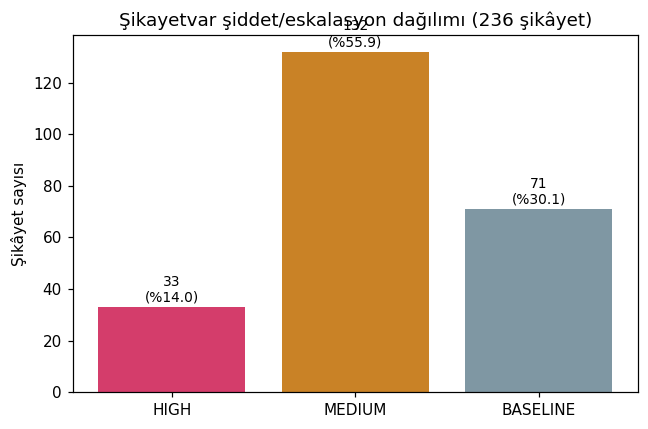

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
order = ["HIGH", "MEDIUM", "BASELINE"]
colors = ["#d43d6b", "#c98226", "#7f97a3"]
d = dist.set_index("severity_tier").loc[order]
ax.bar(order, d["complaint_count"], color=colors)
for i, (n, pct) in enumerate(zip(d["complaint_count"], d["share_pct"])):
    ax.text(i, n + 2, f"{n}\n(%{pct:.1f})", ha="center", fontsize=9)
ax.set_ylabel("Şikâyet sayısı")
ax.set_title("Şikayetvar şiddet/eskalasyon dağılımı (236 şikâyet)")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_severity_distribution.png")
plt.show()


## Severity by aspect — which topics carry the most escalated language

In [7]:
by_aspect = severity_by_aspect_table(nlp)
by_aspect.to_csv(ROOT / "reports/sikayetvar_severity_by_aspect.csv", index=False)
by_aspect


,aspect,complaint_count,high_share_pct,medium_share_pct,baseline_share_pct
0,SAFETY_SECURITY,52,30.769231,40.384615,28.846154
1,CHECKIN_CHECKOUT,4,25.000000,25.000000,50.000000
2,AIR_CONDITIONING,19,21.052632,52.631579,26.315789
3,FAMILY_CHILDREN,53,18.867925,69.811321,11.320755
4,FOOD_BEVERAGE,122,18.852459,63.934426,17.213115
5,STAFF_SERVICE,159,16.981132,62.893082,20.125786
6,MANAGEMENT_COMMUNICATION,140,16.428571,60.000000,23.571429
7,ROOM,142,16.197183,66.197183,17.605634
8,CLEANLINESS_HYGIENE,106,16.037736,67.924528,16.037736
9,PAYMENT_REFUND,123,14.634146,57.723577,27.642276


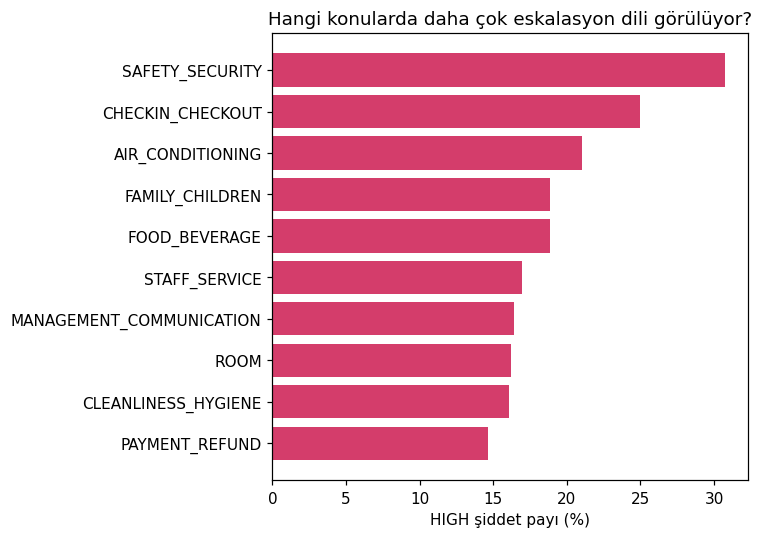

In [8]:
top = by_aspect.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top["aspect"], top["high_share_pct"], color="#d43d6b")
ax.set_xlabel("HIGH şiddet payı (%)")
ax.set_title("Hangi konularda daha çok eskalasyon dili görülüyor?")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_severity_by_aspect.png")
plt.show()


## Save complaint-level severity columns

In [9]:
keep_cols = [
    "complaint_id", "hotel_id", "hotel_name", "area", "complaint_date_raw",
    "company_response_exists_clean" if "company_response_exists_clean" in nlp.columns else "company_response_exists",
    "aspect_count", "matched_aspects",
    "severity_tier", "severity_high_keywords", "severity_medium_keywords", "severity_keyword_count",
]
keep_cols = [c for c in keep_cols if c in nlp.columns]
out = nlp[keep_cols]
out.to_csv(ROOT / "data/processed/sikayetvar_complaints_severity.csv", index=False)
print(out.shape)
out.head(3)


(236, 12)


,complaint_id,hotel_id,hotel_name,area,complaint_date_raw,company_response_exists_clean,aspect_count,matched_aspects,severity_tier,severity_high_keywords,severity_medium_keywords,severity_keyword_count
0,arin-resort-bodrum-memnuniyetsizligi,BOD158,Arin Resort Bodrum,Turgutreis,27 Haziran 2025 11:39,False,4,AIR_CONDITIONING|FOOD_BEVERAGE|ROOM|STAFF_SERVICE,BASELINE,,,0
1,plaj-yaniltmasi-ve-guvenlik-endisesi-nedeniyle...,BOD112,Azure By Yelken Hotel,Kadıkalesi,24 Ağustos 14:01,False,9,BEACH_SEA|FACILITIES_MAINTENANCE|FAMILY_CHILDR...,MEDIUM,,mağdur,1
2,soz-verilen-2500-tl-kampanya-odulu-alinmadi-ve...,BOD112,Azure By Yelken Hotel,Kadıkalesi,12 Ağustos 20:04,False,4,MANAGEMENT_COMMUNICATION|PAYMENT_REFUND|RESERV...,MEDIUM,,mağdur,1


## A few real HIGH-tier examples (qualitative sanity check, not for the report)

In [10]:
for _, r in nlp[nlp.severity_tier == "HIGH"][["hotel_name", "severity_high_keywords", "complaint_text"]].head(3).iterrows():
    print(r["hotel_name"], "|", r["severity_high_keywords"])
    print(str(r["complaint_text"])[:200], "...")
    print("---")


Azure By Yelken Hotel | tehlike
Azure by Yelken Otel Bodrum - Hijyen ve Hizmet Kalitesinde Büyük Hayal Kırıklığı
Azure by Yelken Otel Bodrum’da 5 gece konakladık, ancak yaşadığımız deneyim tam anlamıyla hayal kırıklığıydı. Otele gir ...
---
Azure By Yelken Hotel | tazminat
8 Ağustos 2025 tarihinde Tatilbudur üzerinden Azure by Yelken Bodrum oteline 3 gece konaklamak üzere giriş yaptım. Otele giriş saati olan 14.00’te resepsiyonda başka bir müşteriyle kavga yaşandığı içi ...
---
Azure By Yelken Hotel | zehirlenme
4-5 Ağustos tarihlerinde abim e** f**, eşi G**f** ve 5 yaşındaki ikiz çocukları c** f** ile c**f**, Azura by Yelken Hotel’de konakladı. Akşam otel restoranında balık yedikten sonra, otelin genel hijye ...
---


## Key findings

- 236 şikâyetin %14,0'ü (33) HIGH — yasal/sağlık/dolandırıcılık/tehdit dili içeriyor; %55,9'u (132) MEDIUM — güçlü memnuniyetsizlik dili; %30,1'i (71) BASELINE — yalnız konu bazlı, eskalasyon dili yok.
- HIGH şiddetli şikâyetler firma yanıtını biraz daha sık alıyor (%21,2) MEDIUM (%15,2) ve BASELINE'a (%16,9) göre — ilişkisel bir gözlem, nedensellik iddia edilmiyor.
- Güvenlik & Sağlık (SAFETY_SECURITY) konusu en yüksek HIGH payına sahip (%30,8) — beklenen bir sonuç, çünkü bu konu zaten sağlık/güvenlik terimleriyle örtüşüyor.
- Gürültü (NOISE) konusunda hiç HIGH şiddetli şikâyet yok (%0) — gürültü şikâyetleri nadiren yasal/sağlık diline taşınıyor.


## Limitations

- Kural tabanlı, sözlük tabanlı bir yöntemdir; bağımsız insan etiketlemesiyle doğrulanmadı (aspect taksonomisiyle aynı metodolojik sınırlılık).
- "Şiddet" burada dilsel eskalasyonu ölçer, gerçek olayın vahametini değil — biri abartılı dille yazabilir, biri sakin dille gerçekten ciddi bir olayı anlatabilir.
- HIGH ve MEDIUM sözlükleri birbirini dışlamıyor bazı terimlerde (örn. "tehlike" hem SAFETY_SECURITY aspect hem HIGH severity sözlüğünde) — bu kasıtlı, iki boyut farklı sorular cevaplıyor (konu vs. dil şiddeti).
- Küçük örneklem (236) nedeniyle otel/bölge bazında HIGH payı kırılımı üretilmedi; yalnız konu (aspect) bazında kırılım güvenilir sayılabilir.
- Firma yanıtı ilişkisi korelasyoneldir; HIGH şikâyetlerin daha çok yanıt alması firmaların önceliklendirdiği anlamına gelebilir ama kanıtlanmadı.
